# 样式迁移


## 简介
本节介绍基于 CNN 的样式迁移

![image.png](./images/neural-style.svg)

- 训练输出图片，而不是网络权重
- 令输出图片与内容图片进入 CNN 在某些层可以匹配
- 令输出图片与样式图片进入 CNN 在某些层可以匹配
- 令输出图片噪音损失低


## 实现


In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


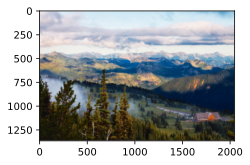

In [2]:
util.set_figsize()
content_img = util.Image.open('./images/rainier.jpg')
util.plt.imshow(content_img)

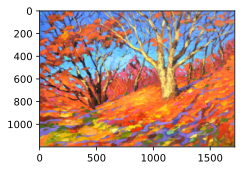

In [3]:
style_img = util.Image.open('./images/autumn-oak.jpg')
util.plt.imshow(style_img)

预处理和后处理


In [24]:
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])
def preprocess(img, image_shape):
    """将图像调整为目标形状并转换为张量"""
    trans = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)])
    return trans(img).unsqueeze(0)  # 增加批量维度

def postprocess(img):
    """将张量转换为图像"""
    img = img[0].to(rgb_std.device)
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1)
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))

抽取特征，用 VGG-19 作为提取器


In [25]:
pretrained_net = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT)

# style_layers 均匀分布，既有局部特征，也有全局特征
# content_layers 只取更抽象的特征，不关注原始细节
style_layers, content_layers = [0, 5, 10, 19, 28], [25]
net = nn.Sequential(*[pretrained_net.features[i] for i in range(max(content_layers) + 1)]) # 28 层之后的丢掉

def extract_features(X):
    """提取内容和样式特征"""
    contents = []
    styles = []
    for i in range(len(net)):
        X = net[i](X) # 一层一层算
        if i in content_layers:
            contents.append(X)
        if i in style_layers:
            styles.append(X)
    return contents, styles

def get_contents(img_shape, device):
    """获取内容特征"""
    content_X = preprocess(content_img, img_shape).to(device)
    contents_Y, _ = extract_features(content_X)
    return content_X, contents_Y
def get_styles(img_shape, device):
    """获取样式特征"""
    styles_X = preprocess(style_img, img_shape).to(device)
    _, styles_Y = extract_features(styles_X)
    return styles_X, styles_Y

定义损失


In [26]:
def content_loss(Y_hat, Y):
    """内容损失"""
    return torch.square(Y_hat - Y.detach()).mean() # MSE

“样式”可以定义为通道内、通道间的统计分布。$Gram$ 矩阵可以捕捉通道间的相关性。

- 给定一个形状为 $(B, C, H, W)$ 的张量 $X$
- $Gram$ 矩阵 $G$ 的形状为 $(B, C, C)$
- 元素 $G[b, i, j]$ 表示第 $b$ 个样本中第 $i$ 个通道和第 $j$ 个通道的内积。

In [27]:
def gram(X):
    """计算 Gram 矩阵"""
    C = X.shape[1]
    n = X.numel() // X.shape[1] # 每个通道的元素个数
    X = X.reshape((C, n)) # 将每个通道拉成一行
    return torch.matmul(X, X.T) / (C * n) # 归一

def style_loss(Y_hat, gram_Y):
    """样式损失"""
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean() # MSE

def tv_loss(Y_hat):
    """总变差损失，每个像素与其相邻像素的差值，表示噪声"""
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

风格迁移的损失是内容、风格、噪声的加权和。


In [39]:
content_w = 1
style_w = 1e4
tv_w = 1e2

def compute_loss(X, content_Y_hat, style_Y_hat, contents_Y, styles_Y):
    """计算总损失"""
    contents_l = [content_loss(Y_hat, Y) * content_w for Y_hat, Y in zip(content_Y_hat, contents_Y)]
    styles_l = [style_loss(Y_hat, Y) * style_w for Y_hat, Y in zip(style_Y_hat, styles_Y)]
    tv_l = tv_loss(X) * tv_w
    l = sum(contents_l + styles_l + [tv_l])
    return contents_l, styles_l, tv_l, l

初始化合成图像


In [40]:
class SynthesizedImage(nn.Module):
    """合成图像"""
    def __init__(self, img_shape):
        super().__init__()
        # 初始化为内容图像
        self.weight = nn.Parameter(torch.randn(img_shape)) # weight 就是图片

    def forward(self):
        return self.weight # 这样可以算梯度

def get_inits(X, device, lr, style_Y):
    """初始化合成图像"""
    gen_img = SynthesizedImage(X.shape).to(device)
    gen_img.weight.data = X.data # 初始化为内容图像
    optimizer = torch.optim.Adam(gen_img.parameters(), lr=lr)
    styles_Y_gram = [gram(Y) for Y in style_Y] # 预计算样式的 Gram 矩阵
    return gen_img(), styles_Y_gram, optimizer

训练


In [41]:
def train(X, contents_Y, styles_Y, device, lr=0.3, num_epochs=200, lr_decay_epochs=50):
    """训练合成图像"""
    X, styles_Y_gram, optimizer = get_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, lr_decay_epochs)
    animator = util.Animator(xlabel='epoch', ylabel='loss', xlim=[10, num_epochs],
                             legend=['content', 'style', 'tv'], ncols=2, figsize=(7, 2.5))
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        content_Y_hat, style_Y_hat = extract_features(X)
        contents_l, styles_l, tv_l, l = compute_loss(X, content_Y_hat, style_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        optimizer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            animator.axes[1].imshow(postprocess(X.detach().cpu()))
            animator.add(epoch + 1,
                         (float(sum(contents_l)),
                          float(sum(styles_l)),
                          float(tv_l)))
    return X

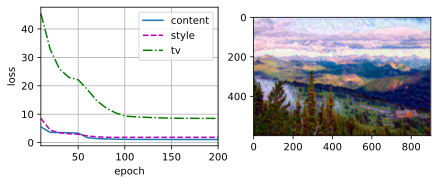

In [42]:
device = util.try_gpu()
img_shape = (600, 900)
net = net.to(device)
content_X, contents_Y = get_contents(img_shape, device)
_, styles_Y = get_styles(img_shape, device)
output = train(content_X, contents_Y, styles_Y, device)

In [43]:
output_img = postprocess(output.detach().cpu())
output_img.save('./images/rainier-stylized.jpg')

最终效果如下

![image.png](./images/rainier-stylized.jpg)
